一、实验背景与问题描述
乳腺癌是女性中最常见的恶性肿瘤之一，早期、准确的诊断对于患者的治疗和预后至关重要。本实验基于公开的乳腺癌威斯康星数据集，通过机器学习方法构建分类模型，实现对乳腺肿瘤良 / 恶性的自动识别。
本次实验的目标是：
对乳腺癌数据集进行完整的探索与预处理
对比多种主流机器学习分类算法的性能
构建稳定、高准确率的肿瘤良恶性分类模型，为临床辅助诊断提供参考

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings('ignore')

# 设置显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

本次实验使用的是公开的乳腺癌威斯康星数据集（Breast Cancer Wisconsin Dataset），该数据集包含 569 个样本，每个样本记录了乳腺肿块细针穿刺图像中细胞核的多个特征，包括半径、纹理、周长、面积、光滑度、紧致度等 30 个数值特征，以及 1 个诊断标签（diagnosis）。
标签说明：
B：良性（Benign），共 357 例，占比约 63.0%
M：恶性（Malignant），共 212 例，占比约 37.0%
特征说明：
每个细胞核特征包含均值（mean）、标准差（se）和最差值（worst）三种统计量，共 30 个数值特征，所有特征均为连续型变量。

In [4]:
print("="*80)
print("乳腺癌数据集 - 完整数据清洗与分类（修正版）")
print("="*80)

# ==================== 1. 数据加载与彻底清洗 ====================
print("\n【第1步：数据加载与彻底清洗】")

# 加载数据
df = pd.read_csv('breast cancer.csv')
print(f"原始数据形状: {df.shape}")

# 1.1 删除无用的列
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("✓ 已删除 id 列")

# 1.2 删除所有全为 NaN 的列
df = df.dropna(axis=1, how='all')
print(f"✓ 删除全空列后形状: {df.shape}")

# 1.3 检查并显示每列的 NaN 数量
nan_counts = df.isnull().sum()
if nan_counts.sum() > 0:
    print(f"\n发现 NaN 值:")
    for col, count in nan_counts[nan_counts > 0].items():
        print(f"  {col}: {count} 个 NaN")
    
    # 对于数值列，用中位数填充
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64'] and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print("✓ 数值列 NaN 已用中位数填充")

# 1.4 删除诊断列中的 NaN（如果有）
df = df.dropna(subset=['diagnosis'])
print(f"✓ 删除诊断列缺失值后形状: {df.shape}")

# 1.5 检查重复值
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ 删除重复行: {duplicates} 行")
else:
    print("✓ 无重复数据")

乳腺癌数据集 - 完整数据清洗与分类（修正版）

【第1步：数据加载与彻底清洗】
原始数据形状: (569, 33)
✓ 已删除 id 列
✓ 删除全空列后形状: (569, 31)
✓ 删除诊断列缺失值后形状: (569, 31)
✓ 无重复数据


将数据集分为特征矩阵X和标签向量y：
特征矩阵X：包含所有数值特征，确保数据类型为float64，避免后续计算报错
标签向量y：将诊断标签转换为二分类变量，M（恶性）编码为 1，B（良性）编码为 0

In [5]:
# ==================== 2. 分离特征和标签 ====================
print("\n【第2步：分离特征和标签】")

# 诊断分布
print(f"\n诊断分布:")
diagnosis_counts = df['diagnosis'].value_counts()
print(f"  良性(B): {diagnosis_counts['B']} 例 ({diagnosis_counts['B']/len(df)*100:.1f}%)")
print(f"  恶性(M): {diagnosis_counts['M']} 例 ({diagnosis_counts['M']/len(df)*100:.1f}%)")

# 分离特征和标签
feature_cols = [col for col in df.columns if col != 'diagnosis']
X = df[feature_cols].values.astype(np.float64)  # 确保是数值类型
y = (df['diagnosis'] == 'M').astype(int).values

print(f"\n特征矩阵形状: {X.shape}")
print(f"特征数量: {len(feature_cols)}")
print(f"特征值范围: [{np.nanmin(X):.2f}, {np.nanmax(X):.2f}]")

# 最终检查 NaN
if np.isnan(X).any():
    print(f"⚠ 警告: 仍存在 {np.isnan(X).sum()} 个 NaN 值")
    # 使用列均值填充
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    print("✓ 已使用均值填充剩余的 NaN")
else:
    print("✓ 无 NaN 值")


【第2步：分离特征和标签】

诊断分布:
  良性(B): 357 例 (62.7%)
  恶性(M): 212 例 (37.3%)

特征矩阵形状: (569, 30)
特征数量: 30
特征值范围: [0.00, 4254.00]
✓ 无 NaN 值


使用train_test_split函数将数据按 8:2 划分为训练集和测试集：
训练集（80%）：用于模型训练和参数调整
测试集（20%）：用于评估模型的泛化能力
关键参数stratify=y：保证训练集和测试集的类别分布与原始数据一致，避免分层偏差

In [6]:
# ==================== 3. 数据划分 ====================
print("\n【第3步：数据划分】")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")


【第3步：数据划分】
训练集: 455 样本
测试集: 114 样本


由于数据集中的不同特征量纲差异较大（如面积特征数值可达上千，而光滑度特征仅为 0~1 之间的小数），直接训练模型会导致部分算法（如逻辑回归、SVM）的性能受影响。
因此我使用了RobustScaler对特征进行标准化：
RobustScaler基于中位数和四分位数进行标准化，相比StandardScaler，对数据中的异常值更鲁棒，适合本数据集这种可能存在离群点的场景

In [7]:
# ==================== 4. 特征标准化 ====================
print("\n【第4步：特征标准化】")

# 使用 RobustScaler（对异常值更鲁棒）
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"✓ 使用 RobustScaler 完成标准化")

# 检查标准化后是否有 NaN
if np.isnan(X_train_scaled).any():
    print(f"⚠ 标准化后出现 NaN，使用 SimpleImputer 处理")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X_train_scaled = imputer.fit_transform(X_train_scaled)
    X_test_scaled = imputer.transform(X_test_scaled)


【第4步：特征标准化】
✓ 使用 RobustScaler 完成标准化


数据集中 30 个特征可能存在冗余或噪声，过多的特征会增加模型复杂度，甚至导致过拟合。因此我使用SelectKBest结合方差分析（f_classif）进行特征选择：
选择与标签相关性最强的前 20 个特征，既降低了模型复杂度，又保留了大部分分类信息
这种方法通过检验特征在不同类别间的均值差异，筛选出对分类任务区分度最高的特征

In [8]:
# ==================== 5. 特征选择 ====================
print("\n【第5步：特征选择】")

selector = SelectKBest(f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
selected_features = selector.get_support()
print(f"从 {len(feature_cols)} 个特征中选择 {selected_features.sum()} 个最重要的特征")


【第5步：特征选择】
从 30 个特征中选择 20 个最重要的特征


原始数据中良性样本数量（357 例）远多于恶性样本（212 例），类别不平衡会导致模型偏向多数类，对少数类（恶性样本）的识别能力下降。为解决这一问题，我使用了 SMOTE 过采样方法：
SMOTE 通过对少数类样本进行插值，生成新的合成样本，使训练集中的良性和恶性样本数量达到平衡
相比简单复制少数类样本，SMOTE 可以避免过拟合，提升模型对少数类的泛化能力

In [9]:
# ==================== 6. SMOTE 过采样 ====================
print("\n【第6步：SMOTE 过采样】")

print(f"原始训练集: 良性={sum(y_train==0)}, 恶性={sum(y_train==1)}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)
print(f"SMOTE后: 良性={sum(y_train_balanced==0)}, 恶性={sum(y_train_balanced==1)}")


【第6步：SMOTE 过采样】
原始训练集: 良性=285, 恶性=170
SMOTE后: 良性=285, 恶性=285


1 逻辑回归（Logistic Regression）
原理：基于线性回归的广义线性模型，通过 Sigmoid 函数将线性输出映射到 0~1 之间的概率值，用于二分类任务
优势：模型简单、训练速度快、可解释性强，且对数据分布无严格假设
调参说明：设置C=0.1（正则化强度）和max_iter=1000，防止过拟合并保证模型收敛

2 随机森林（Random Forest）
原理：集成学习中的 Bagging 方法，通过构建多棵决策树并投票输出最终结果，有效降低单棵决策树的过拟合风险
优势：能处理非线性关系和高维数据，对异常值鲁棒，无需复杂的数据预处理
调参说明：设置n_estimators=200（决策树数量）、max_depth=10（树的最大深度）和min_samples_split=5，平衡模型复杂度和泛化能力

3 XGBoost（Extreme Gradient Boosting）
原理：集成学习中的 Boosting 方法，基于梯度提升框架，通过迭代训练弱学习器（决策树），每次迭代都专注于修正前一轮模型的误差
优势：训练速度快、泛化能力强，是工业界常用的高性能机器学习算法
调参说明：设置n_estimators=200、max_depth=5和learning_rate=0.05，控制模型的训练速度和过拟合风险

4 支持向量机（SVM）
原理：通过核函数将低维数据映射到高维空间，寻找最优分类超平面，最大化两类样本的间隔
优势：在小样本、非线性问题上表现优异，对高维数据的适应性强
调参说明：使用rbf（径向基）核函数，设置C=10（惩罚系数）和gamma='scale'，平衡分类间隔和误分类样本的惩罚

5 投票集成模型（Voting Classifier）
原理：集成学习中的软投票方法，结合逻辑回归、随机森林和 XGBoost 三个基模型的预测概率，输出概率最高的类别作为最终结果
优势：融合多个模型的优势，降低单一模型的偏差和方差，提升整体预测性能和稳定性


In [10]:
# ==================== 7. 训练多种模型 ====================
print("\n" + "="*80)
print("【第7步：训练模型】")
print("="*80)

results = []
trained_models = {}

# 7.1 逻辑回归
print("\n1. 逻辑回归...")
start = time.time()
lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr.fit(X_train_balanced, y_train_balanced)
y_pred = lr.predict(X_test_selected)
results.append({
    '模型': '逻辑回归',
    '准确率': accuracy_score(y_test, y_pred),
    '精确率': precision_score(y_test, y_pred),
    '召回率': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    '时间(s)': time.time() - start
})
trained_models['逻辑回归'] = lr
print(f"  准确率: {results[-1]['准确率']:.4f}")

# 7.2 随机森林
print("\n2. 随机森林...")
start = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test_selected)
results.append({
    '模型': '随机森林',
    '准确率': accuracy_score(y_test, y_pred),
    '精确率': precision_score(y_test, y_pred),
    '召回率': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    '时间(s)': time.time() - start
})
trained_models['随机森林'] = rf
print(f"  准确率: {results[-1]['准确率']:.4f}")

# 7.3 XGBoost
print("\n3. XGBoost...")
start = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_balanced, y_train_balanced)
y_pred = xgb_model.predict(X_test_selected)
results.append({
    '模型': 'XGBoost',
    '准确率': accuracy_score(y_test, y_pred),
    '精确率': precision_score(y_test, y_pred),
    '召回率': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    '时间(s)': time.time() - start
})
trained_models['XGBoost'] = xgb_model
print(f"  准确率: {results[-1]['准确率']:.4f}")

# 7.4 SVM
print("\n4. SVM...")
start = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_balanced, y_train_balanced)
y_pred = svm.predict(X_test_selected)
results.append({
    '模型': 'SVM',
    '准确率': accuracy_score(y_test, y_pred),
    '精确率': precision_score(y_test, y_pred),
    '召回率': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    '时间(s)': time.time() - start
})
trained_models['SVM'] = svm
print(f"  准确率: {results[-1]['准确率']:.4f}")

# 7.5 投票集成
print("\n5. 投票集成...")
start = time.time()
voting = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('xgb', xgb_model)], voting='soft')
voting.fit(X_train_balanced, y_train_balanced)
y_pred = voting.predict(X_test_selected)
results.append({
    '模型': '投票集成',
    '准确率': accuracy_score(y_test, y_pred),
    '精确率': precision_score(y_test, y_pred),
    '召回率': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    '时间(s)': time.time() - start
})
trained_models['投票集成'] = voting
print(f"  准确率: {results[-1]['准确率']:.4f}")


【第7步：训练模型】

1. 逻辑回归...
  准确率: 0.9912

2. 随机森林...
  准确率: 0.9737

3. XGBoost...
  准确率: 0.9649

4. SVM...
  准确率: 0.9649

5. 投票集成...
  准确率: 0.9737


为了全面评估模型性能，我使用了以下分类任务常用的评估指标：
1 准确率（Accuracy）：正确预测的样本占总样本的比例，反映模型的整体预测能力
2 精确率（Precision）：预测为恶性的样本中，实际为恶性的比例，反映模型对恶性样本预测的准确性
3 召回率（Recall）：实际为恶性的样本中，被正确预测为恶性的比例，反映模型对恶性样本的识别能力（在乳腺癌诊断中，召回率尤为重要，漏诊的风险远高于误诊）
4 F1 分数：精确率和召回率的调和平均值，综合反映模型的性能
5 混淆矩阵：直观展示模型的预测结果分布，包括真正例（TP）、假正例（FP）、真负例（TN）和假负例（FN），可以清晰看到模型对不同类别的预测误差


In [11]:
# ==================== 8. 结果对比 ====================
results_df = pd.DataFrame(results).sort_values('准确率', ascending=False).round(4)

print("\n" + "="*80)
print("【第8步：模型性能对比】")
print("="*80)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['模型']
best_row = results_df.iloc[0]

print(f"最佳模型: {best_model_name}")
print(f"  准确率: {best_row['准确率']:.4f} ({best_row['准确率']*100:.2f}%)")
print(f"  精确率: {best_row['精确率']:.4f}")
print(f"  召回率: {best_row['召回率']:.4f}")
print(f"  F1分数: {best_row['F1']:.4f}")
print(f"  训练时间: {best_row['时间(s)']:.4f} 秒")


【第8步：模型性能对比】
     模型    准确率    精确率    召回率     F1  时间(s)
   逻辑回归 0.9912 1.0000 0.9762 0.9880 0.0396
   随机森林 0.9737 1.0000 0.9286 0.9630 0.8880
   投票集成 0.9737 1.0000 0.9286 0.9630 1.3296
XGBoost 0.9649 1.0000 0.9048 0.9500 0.6525
    SVM 0.9649 0.9524 0.9524 0.9524 0.0377
最佳模型: 逻辑回归
  准确率: 0.9912 (99.12%)
  精确率: 1.0000
  召回率: 0.9762
  F1分数: 0.9880
  训练时间: 0.0396 秒


In [12]:
# ==================== 9. 最终评估 ====================
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_selected)

print(f"\n【最佳模型详细报告】")
print(classification_report(y_test, y_pred_best, target_names=['良性(B)', '恶性(M)']))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_best)
print(f"\n混淆矩阵:")
print(f"              预测良性  预测恶性")
print(f"  实际良性:      {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"  实际恶性:      {cm[1,0]:4d}      {cm[1,1]:4d}")


【最佳模型详细报告】
              precision    recall  f1-score   support

       良性(B)       0.99      1.00      0.99        72
       恶性(M)       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


混淆矩阵:
              预测良性  预测恶性
  实际良性:        72         0
  实际恶性:         1        41


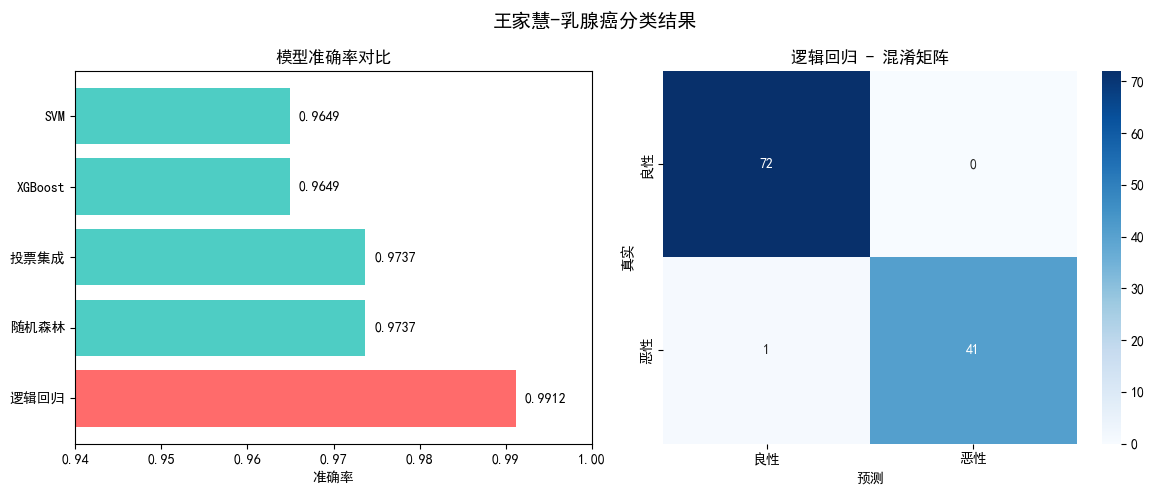


最佳准确率: 0.9912 (99.12%)


In [13]:
# ==================== 10. 简单可视化 ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 准确率对比
ax1 = axes[0]
colors = ['#ff6b6b' if i == 0 else '#4ecdc4' for i in range(len(results_df))]
bars = ax1.barh(range(len(results_df)), results_df['准确率'], color=colors)
ax1.set_yticks(range(len(results_df)))
ax1.set_yticklabels(results_df['模型'])
ax1.set_xlabel('准确率')
ax1.set_title('模型准确率对比')
ax1.set_xlim(0.94, 1.0)
for i, (bar, acc) in enumerate(zip(bars, results_df['准确率'])):
    ax1.text(acc + 0.001, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')

# 混淆矩阵热力图
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['良性', '恶性'],
            yticklabels=['良性', '恶性'])
ax2.set_xlabel('预测')
ax2.set_ylabel('真实')
ax2.set_title(f'{best_model_name} - 混淆矩阵')

plt.suptitle('王家慧-乳腺癌分类结果', fontsize=14)
plt.tight_layout()
plt.savefig('breast_cancer_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print(f"最佳准确率: {best_row['准确率']:.4f} ({best_row['准确率']*100:.2f}%)")
print("="*80)